In [10]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/rnn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/rnn


In [11]:
%pip install -q pandas numpy scikit-learn tensorflow

In [12]:
!python train.py --epochs 100 --batch-size 64

2026-05-19 03:33:54.925839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Rebuilding bitcoin_features_daily.csv because it is missing new feature columns.
2026-05-19 03:34:20.220831: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779161660.222420   12386 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

CV fold 1/5: train 2012-01-30 00:00:00+00:00 -> 2014-02-10 00:00:00+00:00 | val 2014-02-11 00:00:00+00:00 -> 2016-02-19 00:00:00+00:00
Epoch 1/100
2026-05-19 03:

In [13]:
!python test.py

2026-05-19 03:35:29.937131: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-19 03:35:37.626406: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779161737.627925   14352 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-05-19 03:35:39.025516: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
Model file: artifacts/best_model.keras
               model         MAE        RMSE  MAPE_percent  direction_accuracy_percent

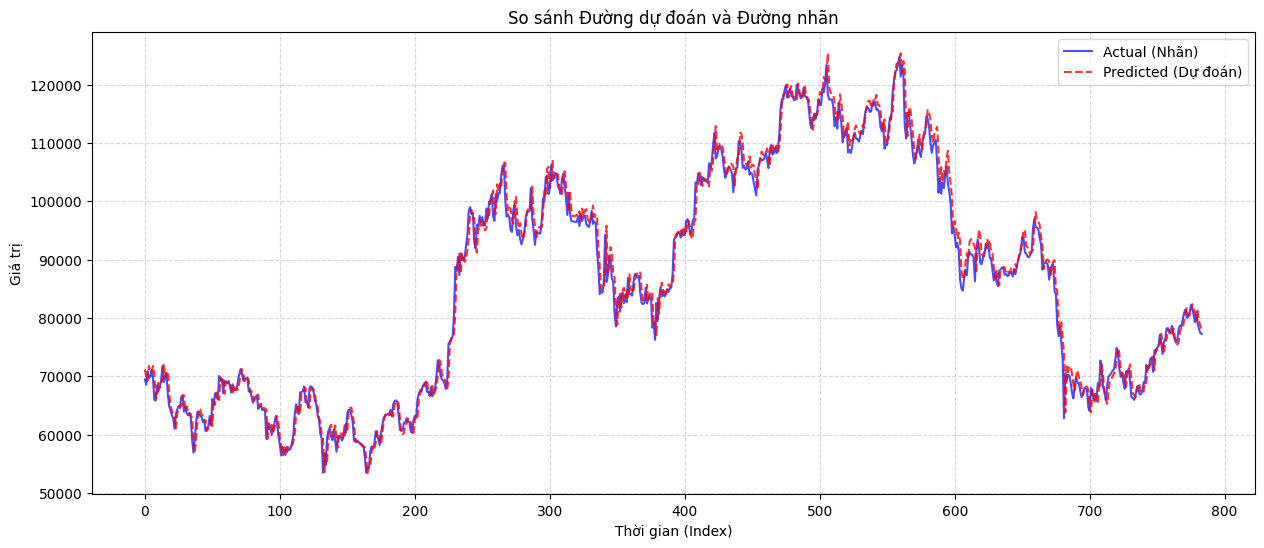

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Đường dẫn tới file predictions
file_path = 'scores/predictions.csv'

if os.path.exists(file_path):
    # Load dữ liệu
    pred_df = pd.read_csv(file_path)

    # Vẽ biểu đồ
    plt.figure(figsize=(15, 6))
    plt.plot(pred_df['actual'], label='Actual (Nhãn)', color='blue', alpha=0.7)
    # Sửa tên cột từ 'prediction' thành 'predicted'
    plt.plot(pred_df['predicted'], label='Predicted (Dự đoán)', color='red', linestyle='--', alpha=0.8)

    plt.title('So sánh Đường dự đoán và Đường nhãn')
    plt.xlabel('Thời gian (Index)')
    plt.ylabel('Giá trị')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print(f'Không tìm thấy file {file_path}. Vui lòng kiểm tra lại quá trình chạy test.')